In [1]:
# This code is generated from Claude AI 
# I need to modify it so that I control the numerical integration
# I also need to convert it to PyTorch so that I can find the numerical deriviative.

In [2]:
# We start by importing all the necessary packages
import matplotlib.pyplot as plt
import numpy as np
from scipy.integrate import solve_ivp
import torch
from tqdm import tqdm
import math
from python_files import base_functions as bf






In [3]:
# We now set all the parameters that we need

# Parameters
N = 40          # Grid points (also L96 dimension)
dx = 1       # Spatial step
alpha = 0.5
beta = 0.6
F_L96 = 4.0     # L96 forcing

In [4]:


# Parameters
N = 40          # Grid points (also L96 dimension)
dx = 0.3        # Spatial step
alpha = 0.5
beta = 0.5
F_L96 = 8.0     # L96 forcing

def lorenz96(u):
    """Standard Lorenz-96 tendency."""
    return (torch.roll(u, -1) - torch.roll(u, 2)) * torch.roll(u, 1) - u + F_L96

# def source_s(u):
#     """Source term s(u) — define as needed."""
#     return 0.1 * u  # Example: linear in u

def source_s(u):
    u = torch.asarray(u)

    M = torch.zeros((len(u), len(u)))

    # find closest indices to 10 and 30
    i1 = 10
    i2 = 30

    M[i1, i1] = 1
    M[i2, i2] = 1

    # print(M)
    
    return torch.matmul(M, ( u**2))
    
    

def advection_upwind(C, u, dx):
    """Upwind advection: -u * dC/dx with periodic BCs."""
    dCdx = torch.where(
        u >= 0,
        (C - torch.roll(C, 1)) / dx,   # Backward diff for u > 0
        (torch.roll(C, -1) - C) / dx   # Forward diff for u < 0
    )
    return -u * dCdx

def rhs(y):
    C = y[:N]
    u = y[N:]
    
    # 1. Advection and Source remain (C depends on u)
    dCdt = advection_upwind(C, u, dx) + source_s(u) - alpha * C
    
    # 2. Modified Lorenz-96 (u depends strongly on C)
    # Standard L96 terms
    L96 = (torch.roll(u, -1) - torch.roll(u, 2)) * torch.roll(u, 1) - u + F_L96
    
    # Strong coupling: Let C modulate the forcing or act as a non-linear drag
    # Example: beta * C * u creates a "state-dependent" damping
    drag = beta * C * u 
    
    dudt = L96 - drag
    
    return torch.cat([dCdt, dudt])


def rk4_step(y, dt):
    k1 = rhs(y)
    k2 = rhs(y + 0.5 * dt * k1)
    k3 = rhs(y + 0.5 * dt * k2)
    k4 = rhs(y + dt * k3)
    
    return y + (dt/6.0) * (k1 + 2*k2 + 2*k3 + k4)


In [5]:
# Parameters
N = 40          # Grid points (also L96 dimension)
dx = 0.3        # Spatial step
alpha = 0.1
beta = 0.01
F_L96 = 8.0     # L96 forcing



C0 = torch.zeros(N)
u0 = F_L96 * torch.ones(N)
u0[0] += 0.01

y = torch.cat([C0, u0])

dt = 0.01
T = 200
steps = int(T/dt)

trajectory = []
times = []
dust_mass = []

t = 0.0

for _ in tqdm(range(steps)):
    trajectory.append(y.clone())  # store current state
    times.append(t)
    
    y = rk4_step(y, dt)
    t += dt
    # print(torch.min(y[:40]))
    dust_mass.append(torch.sum(y[:40]))


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T

100%|██████████| 20000/20000 [00:03<00:00, 6269.97it/s]


torch.Size([40, 20000])


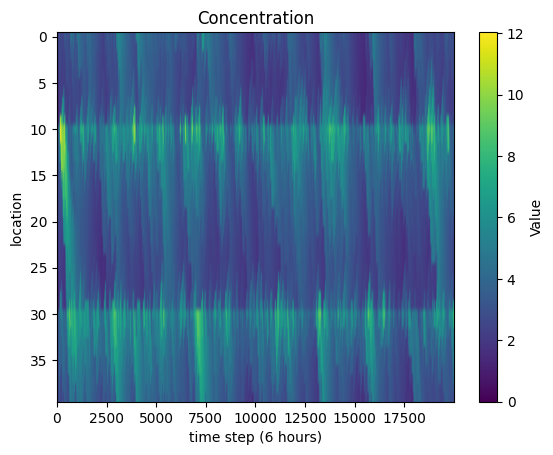

In [6]:
print(C_sol.shape)

plt.imshow(C_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Concentration")
plt.show()

Text(0.5, 1.0, 'Mass in system over time')

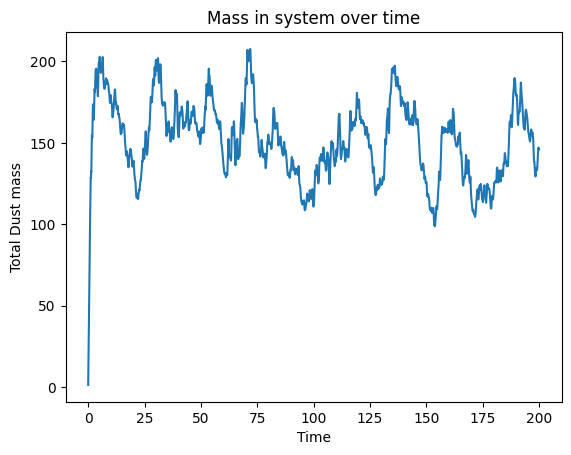

In [7]:
plt.plot(times, dust_mass)

# 3. Add labels and a title
plt.xlabel('Time')
plt.ylabel('Total Dust mass')
plt.title('Mass in system over time')



torch.Size([40, 20000])


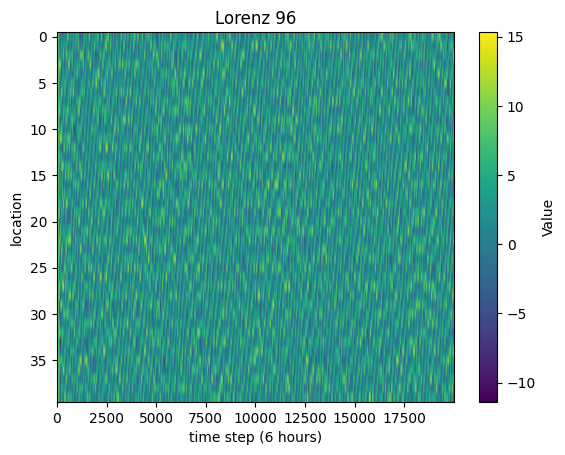

In [8]:
print(u_sol.shape)


plt.imshow(u_sol,aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title("2D Tensor Heatmap")
plt.xlabel("time step (6 hours)")
plt.ylabel("location") 
plt.title("Lorenz 96")
plt.show()

In [9]:
# We will now attempt to find the Jacobian of the coupled system
# delx = torch.tensor(delx, dtype=torch.float32, requires_grad=True)
# delt = torch.tensor(delt, dtype=torch.float32, requires_grad=True)

# inputs = (y,dt)
# der_model = torch.autograd.functional.jacobian(rk4_step,inputs)
y = y.clone().detach().requires_grad_(True)

J = torch.autograd.functional.jacobian(
    lambda y: rk4_step(y, dt),
    y
)
print(J.shape)


torch.Size([80, 80])


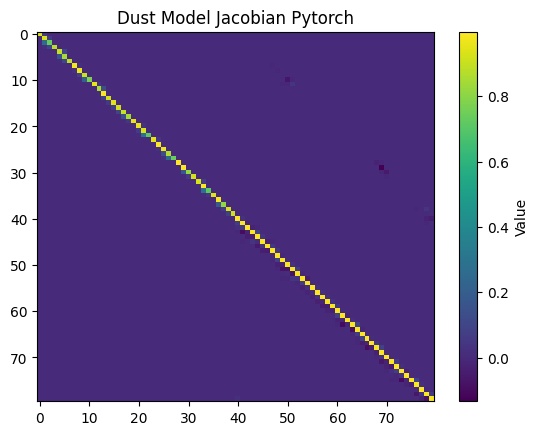

In [10]:
plt.imshow(J.cpu().numpy(),aspect='auto', cmap='viridis')

plt.colorbar(label='Value')
plt.title("Dust Model Jacobian Pytorch")
plt.show()

In [11]:
# We start by running the model for 400 time steps
x_in = torch.rand((2*N,1))
results = x_in
delx = 1
delt = 0.005 # 6 hours according to Lorenz
time_steps = 14400 # this is ten years according to Lorenz 


for i in tqdm(range(1000)):
    x_out = rk4_step(x_in, dt)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out
    plot = x_in.cpu().numpy().flatten()

    # plt.plot(plot)
    # plt.title(f"Step {i}")
    # plt.xlabel("Index")
    # plt.ylabel("Value")
    # plt.savefig(f'/Users/isaacmiles-fine/Documents/PhD/2026/Lorenz_pytorch/first_run/plot_{i+1}.png')
    # plt.close()



100%|██████████| 1000/1000 [00:00<00:00, 6228.39it/s]


In [12]:
C0 = torch.zeros(N)
u0 = F_L96 * torch.ones(N)
u0[0] += 0.01

y = torch.cat([C0, u0])

dt = 0.01
T = 30
steps = int(T/dt)

trajectory = []
times = []

t = 0.0

for _ in tqdm(range(400)):
    trajectory.append(y.clone())  # store current state
    times.append(t)
    
    y = rk4_step(y, dt)
    t += dt


trajectory = torch.stack(trajectory)  # shape: (steps, 2N)
times = torch.tensor(times)
C_sol = trajectory[:, :N].T   # shape: (time, space)
u_sol = trajectory[:, N:].T
x_out= y
print(x_out.shape)

100%|██████████| 400/400 [00:00<00:00, 6675.03it/s]

torch.Size([80])


We want to see how well the TLM can emulate the small perturbation
$|J(x + x',A) - J(x,A) - \frac{\partial J}{\partial x} x'|$

In [13]:
# We will now add a small perturbation
x_pert = torch.rand(2*N)*10**(-5)
print(x_pert.shape)
x_in_pert = x_out + x_pert
x_out_pert = rk4_step(x_in_pert, dt)
x_out_unpert = rk4_step(x_out, dt)
# print(x_out_unpert.shape)
TLM_test = x_out_pert - x_out_unpert - torch.matmul(J, x_pert)
# print(TLM_test.shape)



torch.Size([80])


In [14]:
error = torch.sum((torch.abs(TLM_test)))
print(error)

tensor(2.7543e-05)


In [15]:
# Now that we have the Jacobian from autograd we will attempt to find the TLM using ensemble methods
ensemble_size = 1000
x_in = torch.rand((2*N,1))
results = x_in
delx = 1
delt = 0.005 # 6 hours according to Lorenz
dt = delt
time_steps = 14400 # this is ten years according to Lorenz 


for i in tqdm(range(1000)):
    x_out = rk4_step(x_in, dt)
    results = torch.cat((results, x_out), dim = 1)
    x_in = x_out

X = torch.zeros(2*N, ensemble_size)
Chi = torch.zeros(2*N, ensemble_size)

for i in tqdm(range(ensemble_size)):
    x_pert = torch.rand(2*N,1)*10**(-5)
    x_in_pert = x_out + x_pert
    x_out_pert = rk4_step(x_in_pert,dt)
    x_out_unpert = rk4_step(x_out, dt)
    Chi_i = x_out_pert - x_out_unpert
    X[:,i] = x_pert.squeeze()
    Chi[:,i] = Chi_i.squeeze()
    
    

100%|██████████| 1000/1000 [00:00<00:00, 3282.38it/s]


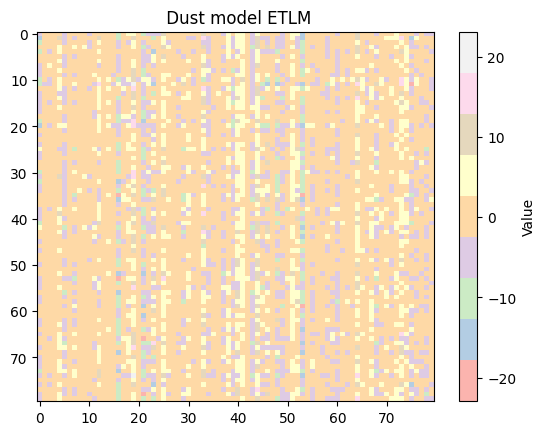

In [88]:
ETLM = Chi @ torch.transpose(X,0,1) @ torch.linalg.inv( torch.matmul(X,  torch.transpose(X,0,1)))
plt.imshow(ETLM.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()

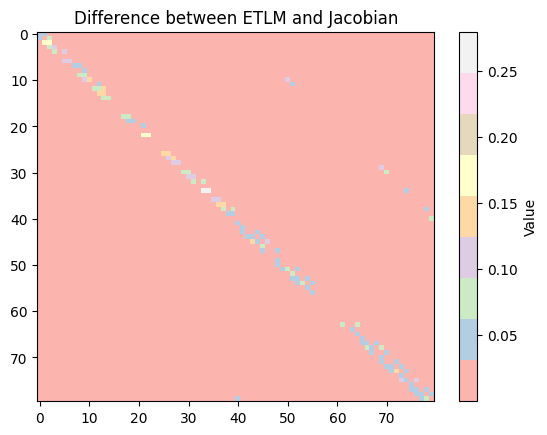

In [17]:
plt.imshow((torch.abs(ETLM- J)).cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Difference between ETLM and Jacobian")
plt.show()

We want to see how well the TLM can emulate the small perturbation
$|J(x + x',A) - J(x,A) - \frac{\partial J}{\partial x} x'|$


In [18]:
# We will now do the same TLM test as before and compare the results
# We will now add a small perturbation
x_pert = torch.rand(2*N,1)*10**(-5)
x_in_pert = x_out + x_pert
x_out_pert = rk4_step(x_in_pert, dt)
x_out_unpert = rk4_step(x_out, dt)
TLM_test = x_out_pert - x_out_unpert - torch.matmul(ETLM, x_pert)
error = torch.sum((torch.abs(TLM_test)))
print(error)

tensor(5.8740e-06)


We will now test the autograd and ETLM with more rigour. We will start by doing 15 trials of one time step with a random perturbation for each trial and then normalising. We will the average the error for each and compare. We will then do the same, but run the model for ten time steps, recomputing the TLMs for each time step.



$NRMSE(\boldsymbol{M}^p) =  \left( \frac{1}{n_{\text{trials}}} \sum_{i=1}^{n_{\text{trials}}} \left\{ \sqrt{\frac{([\mathscr{M}(\boldsymbol{x}_0^s - \mathscr{M}(\boldsymbol{x}_0^g) - \boldsymbol{M}^p \delta \boldsymbol{x}_0^s)^T([\mathscr{M}(\boldsymbol{x}_0^s - \mathscr{M}(\boldsymbol{x}_0^g) - \boldsymbol{M}^p \delta \boldsymbol{x}_0^s)}{[\mathscr{M}(\boldsymbol{x}_0^s - \mathscr{M}(\boldsymbol{x}_0^g)]^T[\mathscr{M}(\boldsymbol{x}_0^s - \mathscr{M}(\boldsymbol{x}_0^g)]}}\right\}_i\right)$


In [19]:
# We will start by defining our error function
def norm_error(x_pert, N, model,dt, M):
    x_in_pert = x_out + x_pert
    x_out_pert = model(x_in_pert, dt)
    x_out_unpert = model(x_out, dt)
    diff = x_out_pert - x_out_unpert - torch.matmul(M, x_pert)
    return diff


def normalisor(sd, N, model,dt):
    x_in_pert = x_out + x_pert
    x_out_pert = model(x_in_pert, dt)
    x_out_unpert = model(x_out, dt)
    norm = x_out_pert - x_out_unpert
    return norm


# We will now define a very quick generic TLM test that will be used for the multistep TLM test 
def generic_TLM_test(diff, norm):
    error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
    return error
    


def TLM_test(sd, N, model,dt, n_trials, M):
    TLM_error = 0
    for i in range(n_trials):
        torch.manual_seed((42*i)**4)
        x_pert = torch.randn(2*N,1)*sd
        # print(x_pert[4])
        diff = norm_error(x_pert, N, model,dt, M)
        norm = normalisor(x_pert, N, model,dt)
        # ith_error = math.sqrt(torch.matmul(diff.T, diff)/torch.matmul(norm.T, norm))
        ith_error = generic_TLM_test(diff, norm)
        TLM_error += ith_error
    return TLM_error/n_trials




    


In [20]:
# We will now test this function for one time step on the ETLM
sd = 10**(-6)
N = 40
model = rk4_step
dt = 0.005
n_trials = 15
M = ETLM
TLM_score = TLM_test(sd, N, model,dt, n_trials, M)
print(TLM_score)


0.02073454587487516


In [21]:
# We will now test this autograd function
sd = 10**(-6)
N = 40
model = rk4_step
dt = 0.005
n_trials = 15
M = J
TLM_score = TLM_test(sd, N, model,dt, n_trials, M)
print(TLM_score)

0.028123611820111364


In [22]:
# We will now define a function that finds that autograd jacobian of the model
def autograd(y, model, dt):
    y = y.clone().detach().requires_grad_(True)
    J = torch.autograd.functional.jacobian(lambda y: model(y, dt),y)
    return J
    

In [23]:
# We will also define a function that find the ETLM of the model 
def ETLM_finder(ensemble_size, x_in, delx, delt, time_steps, model):
    ensemble_size = 2 * N + 100
    X = torch.zeros(2*N, ensemble_size)
    Chi = torch.zeros(2*N, ensemble_size)

    for i in range(ensemble_size):
        torch.manual_seed((629*i)**2)
        
        x_pert = torch.rand(2*N,1)*sd
        x_in_pert = x_in + x_pert
        x_out_pert = model(x_in_pert,dt)
        x_out_unpert = model(x_in, dt)
        Chi_i = x_out_pert - x_out_unpert
        X[:,i] = x_pert.squeeze()
        Chi[:,i] = Chi_i.squeeze()

    ETLM = Chi @ torch.transpose(X,0,1) @ torch.linalg.inv( torch.matmul(X,  torch.transpose(X,0,1)))
    return ETLM
    
    
        

In [24]:
# Chat GPT version
def ETLM_finder(ensemble_size, x_in, sd, dt, model):
    dim = x_in.shape[0]

    X = torch.zeros((dim, ensemble_size))
    Chi = torch.zeros((dim, ensemble_size))

    # ✅ Compute unperturbed ONCE
    x_out = model(x_in, dt)

    for i in range(ensemble_size):
        x_pert = torch.rand((dim, 1)) * sd

        x_out_pert = model(x_in + x_pert, dt)

        Chi[:, i] = (x_out_pert - x_out).squeeze()
        X[:, i] = x_pert.squeeze()

    # ✅ Use pinv instead of inv
    ETLM = Chi @ X.T @ torch.linalg.inv(X @ X.T)

    # ✅ Return BOTH
    return ETLM, x_out

In [79]:
# We will now devise a function that means we can run the TLM test across multiple time steps
def TLM_test_multi_step(sd, N, model, dt, n_steps, TLM_type, seed, sut, start_seed = 371):
    # We first define our starting state vector
    torch.manual_seed(start_seed)
    x_in = torch.rand((2*N,1))

    # we start by finding the TLM of the model
    if TLM_type == 'autodiff':
        # we start by spinning up the model 
        for i in range(sut):
            x_out = model(x_in, dt)
            x_in = x_out
        
        torch.manual_seed(seed)
        test_pert = torch.rand(2*N,1)*sd
        u_test = x_out + test_pert

        for i in range(n_steps):
            # we first calculate the ETLM for this step
            J = autograd(y, model, dt).T

            # We now run the model forward 1 time step on the perturbed, unperturbed and the perturbation
            # the unperturbed
            x_out = model(x_in, dt)
            x_in = x_out

            # the perturbed
            u_test = model(u_test, dt)

            # the perturbation
            test_pert = torch.matmul(J, test_pert)
        
        # we will now run the TLM test to see the error 
        diff = u_test - x_out - test_pert
        norm = u_test - x_out
        error = generic_TLM_test(diff, norm)
        return error
            


    # We will now do the version if the TLM is the ETLM 
    elif TLM_type == 'ETLM':
        # we start by spinning up the model 
        for i in range(sut):
            x_out = model(x_in, dt)
            x_in = x_out
        
        torch.manual_seed(seed)
        test_pert = torch.rand(2*N,1)*sd
        u_test = x_out + test_pert

        
        for i in range(n_steps):
            # we first calculate the ETLM for this step
            # etlm = ETLM_finder(ensemble_size, x_in, delx, delt, time_steps, model)

            # # We now run the model forward 1 time step on the perturbed, unperturbed and the perturbation
            
            # # the unperturbed
            # x_out = model(x_in, dt)
            # x_in = x_out

            # # the perturbed
            # u_test = model(u_test, dt)

            # # the perturbation
            # test_pert = torch.matmul(etlm, test_pert)


            etlm, x_out = ETLM_finder(ensemble_size, x_in, sd, dt, model)

            # propagate perturbed state
            u_test = model(u_test, dt)

            # propagate perturbation
            test_pert = torch.matmul(etlm, test_pert)

            # update base state
            x_in = x_out
        
        # we will now run the TLM test to see the error 
        diff = u_test - x_out - test_pert
        norm = u_test - x_out
        error = generic_TLM_test(diff, norm)
        return error
    else:
        return "not a valid TLM type"
    


In [80]:
sd = 10**(-6)
N = 40
model = rk4_step
dt = 0.005
n_steps = 1
TLM_type = 'autodiff'
seed = 18
sut = 1000

err0r = TLM_test_multi_step(sd, N, model, dt, n_steps, TLM_type, seed, sut)
print(err0r)

0.13265835708679097


In [27]:
sd = 10**(-6)
N = 40
model = rk4_step
dt = 0.005
n_steps = 6
TLM_type = 'ETLM'
seed = 18
sut = 1000

err0r = TLM_test_multi_step(sd, N, model, dt, n_steps, TLM_type, seed, sut)
print(err0r)

0.5960987715803344


In [28]:
# We will now define a function that will do the multi step test for multiple trials
def ms_ms_TLM_test(n_trials,sd, N, model, dt, n_steps, TLM_type, sut):
    TLM_error = 0
    for trial in range(n_trials):
        seed = (23*trial)**7
        trial_error = TLM_test_multi_step(sd, N, model, dt, n_steps, TLM_type, seed, sut)
        TLM_error += trial_error
    return TLM_error/n_trials

    

In [83]:
# Setting the parameters
sd = 10**(-8)
N = 40
model = rk4_step
dt = 0.005
n_steps = 1
TLM_type = 'autodiff'
sut = 1000
n_trials = 10

# Running the test
error = ms_ms_TLM_test(n_trials,sd, N, model, dt, n_steps, TLM_type, sut)
# Printing the result
print(error)


1.9110572899878098


In [84]:
sd = 10**(-8)
N = 40
model = rk4_step
dt = 0.005
n_steps = 1
TLM_type = 'ETLM'
sut = 1000
n_trials = 10

# Running the test
error = ms_ms_TLM_test(n_trials,sd, N, model, dt, n_steps, TLM_type, sut)
# Printing the result
print(error)


31.97028776633241


In [85]:
sd = 10**(-8)
N = 40
model = rk4_step
dt = 0.005
TLM_type = 'ETLM'
sut = 1000
n_trials = 10

num_steps = [1,2,3,4,5,6,7,8,9,10]
errors_etlm = []

for steps in num_steps:
    error = ms_ms_TLM_test(n_trials, sd, N, model, dt, steps, TLM_type, sut)
    errors_etlm.append(error)

In [86]:
sd = 10**(-8)
N = 40
model = rk4_step
dt = 0.005
TLM_type = 'autodiff'
sut = 1000
n_trials = 10

num_steps = [1,2,3,4,5,6,7,8,9,10]
errors_ad = []

for steps in num_steps:
    error = ms_ms_TLM_test(n_trials, sd, N, model, dt, steps, TLM_type, sut)
    errors_ad.append(error)

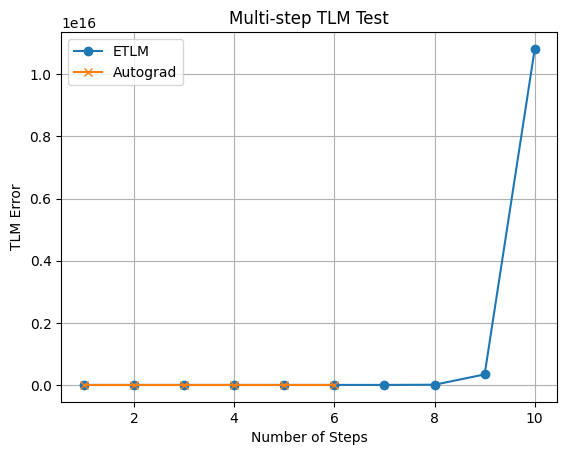

In [87]:


plt.plot(num_steps, errors_etlm, marker='o', label = 'ETLM')
plt.plot(num_steps, errors_ad, marker='x', label = 'Autograd')
plt.xlabel("Number of Steps")
plt.ylabel("TLM Error")
plt.title("Multi-step TLM Test")
plt.legend()
plt.grid()
plt.show()

In [34]:
# I will now be attempting to make the LETLM of this model

In [35]:
def ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time):
    # we first extract the model variables
    (dt, dx, N, n, alpha, beta, F_96) = model_parameters
    # we now run the model to spin up the model
    x_in = torch.rand((2*N,1))
    results = x_in
    for i in tqdm(range(spin_up_time)):
        x_out = rk4_step(x_in, dt)
        results = torch.cat((results, x_out), dim = 1)
        x_in = x_out

    # We will create the tensors to hold the ensembles
    number_of_variables = n * N # n = number of varables at each point and N = number of points
    Xi = torch.zeros(number_of_variables, ensemble_size)
    X = torch.zeros(number_of_variables, ensemble_size)
    Chi = torch.zeros(number_of_variables, ensemble_size)

    for i in range(ensemble_size):
        x_pert = torch.rand(number_of_variables,1) * perturbation_size
        x_in_pert = x_out + x_pert
        x_out_pert = model(x_in_pert,dt)
        x_out_unpert = model(x_out, dt)
        Xi_i = x_out_pert - x_out_unpert
        X[:,i] = x_pert.squeeze()
        Xi[:,i] = Xi_i.squeeze()
        x_out_pert = model(x_in_pert,dt)
        x_out_unpert = model(x_out, dt)
        Chi_i = x_out_pert - x_out_unpert
        Chi[:,i] = Chi_i.squeeze()
    return X, Xi, Chi
    

In [36]:
# We will now test this function
# We start by setting the parameters that we need
# We will start with the model parameters
dt = 0.01
dx = 0.3
N = 40
n = 2
alpha = 0.5
beta = 0.2
F_96 = 8
model_parameters = (dt, dx, N, n, alpha, beta, F_96)
ensemble_size = 12
model = rk4_step
spin_up_time = 1000
perturbation_size = 10**(-5)



X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

100%|██████████| 1000/1000 [00:00<00:00, 5896.57it/s]


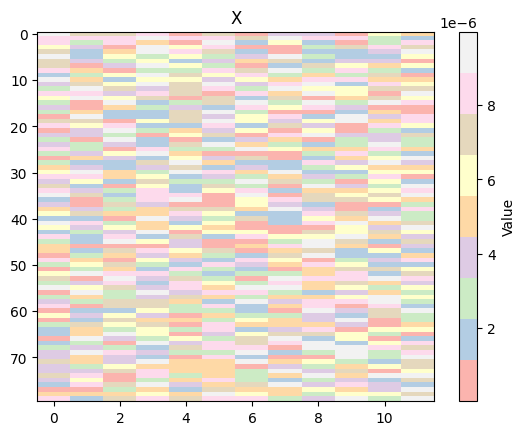

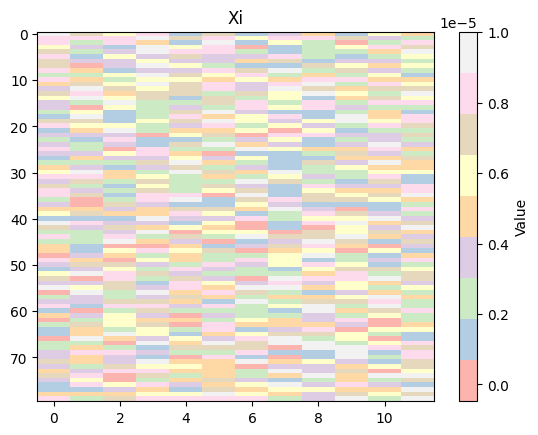

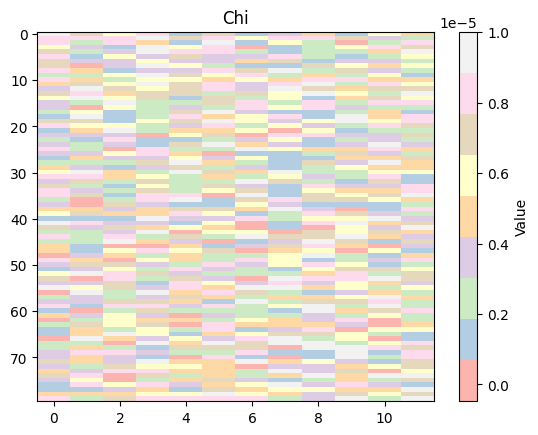

In [37]:
plt.imshow(X.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("X")
plt.show()
plt.imshow(Xi.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Xi")
plt.show()
plt.imshow(Chi.cpu().numpy(),aspect='auto', cmap='Pastel1')
plt.colorbar(label='Value')
plt.title("Chi")
plt.show()


In [38]:
def member_selector(i, members, ensemble, ensemble_size, N, n):
    subset = torch.zeros(len(members), ensemble_size)
    
    for j in range(ensemble_size):
        for k in range(len(members)):
            subset[k, j] = ensemble[members[k] % (n * N), j]
    
    return subset

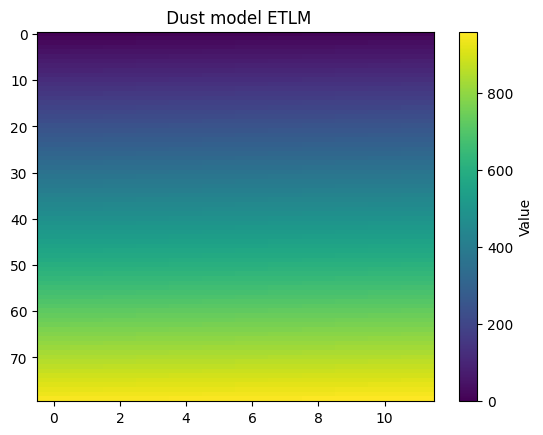

tensor([[  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11],
        [ 12,  13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23],
        [ 24,  25,  26,  27,  28,  29,  30,  31,  32,  33,  34,  35],
        [ 36,  37,  38,  39,  40,  41,  42,  43,  44,  45,  46,  47],
        [ 48,  49,  50,  51,  52,  53,  54,  55,  56,  57,  58,  59],
        [ 60,  61,  62,  63,  64,  65,  66,  67,  68,  69,  70,  71],
        [ 72,  73,  74,  75,  76,  77,  78,  79,  80,  81,  82,  83],
        [ 84,  85,  86,  87,  88,  89,  90,  91,  92,  93,  94,  95],
        [ 96,  97,  98,  99, 100, 101, 102, 103, 104, 105, 106, 107],
        [108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119],
        [120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131],
        [132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143],
        [144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155],
        [156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167],
        [168, 169, 1

In [39]:
# We will now test this function
rows = 80
cols = ensemble_size


test_ensemble = torch.arange(0, rows * cols).reshape(rows, cols)

# test_ensemble = torch.arange(0, rows * cols).reshape(rows, cols)

# col = torch.arange(0, 2*N )
# test_ensemble = col.unsqueeze(1).repeat(1, ensemble_size)
plt.imshow(test_ensemble.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()
print(test_ensemble)


torch.Size([6, 12])


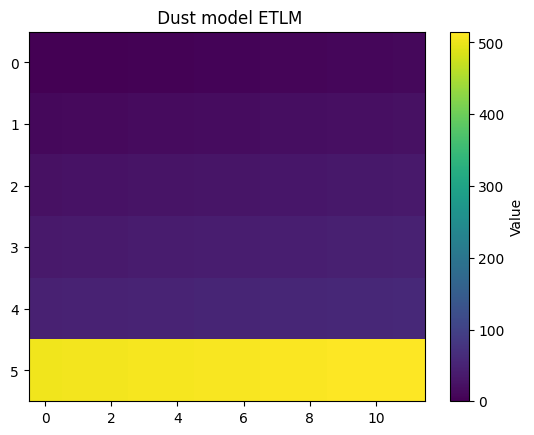

tensor([[  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.],
        [ 12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.],
        [ 24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.],
        [ 36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.],
        [ 48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.],
        [504., 505., 506., 507., 508., 509., 510., 511., 512., 513., 514., 515.]])


In [40]:
i = 2
ensemble_size = 12
members = (i-2,i-1, i,i+1, i + 2, i + N)
subset = member_selector(i, members, test_ensemble, ensemble_size, N, n)
print(subset.shape)
plt.imshow(subset.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()
print(subset)

In [41]:
def J_cost_function(localised_ensembles, members):
    # we first construct the Pi matrix
    Pi_half = localised_ensembles[0]
    for ii in range(len(localised_ensembles) -1):
        print(Pi_half.shape)
        Pi_half = torch.stack((Pi_half, (-1) * localised_ensembles[ii+1]),dim = 2)
        
    
    Pi = torch.matmul(Pi_half, Pi_half.T)
    print(Pi.shape)
    eigs = torch.linalg.eig(Pi)
    # print(eigs)

    return eigvals, eigvecs





# def J_cost_function(localised_ensembles, members):
#     # Stack all ensemble components properly
#     for i, t in enumerate(localised_ensembles):
#         print(f"Tensor {i} shape:", t.shape)
#     Pi_half_list = [localised_ensembles[0]]
    
#     for ii in range(1, len(localised_ensembles)):
#         Pi_half_list.append(-1 * localised_ensembles[ii])
    
#     Pi_half = torch.stack(Pi_half_list)
    
#     # Compute Pi = Pi_half * Pi_half^T
#     Pi = torch.matmul(Pi_half, Pi_half.T)
#     # print(Pi.shape)
    
#     # Use eigh for symmetric matrices
#     eigvals, eigvecs = torch.linalg.eigh(Pi)
    
#     return eigvals, eigvecs


    # return X_i_tilde, Xi_i_tilde, Chi_i_tilde




In [76]:
def J_cost_function(localised_ensembles, members):
    Pi_half_list = []

    for ii, tensor in enumerate(localised_ensembles):
        # print(f"Input {ii} shape:", tensor.shape)

        if ii == 0:
            Pi_half_list.append(tensor)
        else:
            Pi_half_list.append(-tensor)

    # stack rows
    Pi_half = torch.cat(Pi_half_list, dim=0).T

    # print("Pi_half shape:", Pi_half.shape)  

    Pi = Pi_half @ Pi_half.T  # (9, 9)
    print("Pi shape:", Pi.shape)

    eigvals, eigvecs = torch.linalg.eigh(Pi)

    zero_eigenval, zero_eigenvecs = torch.lobpcg(Pi, k = 2)

    # return eigvals, eigvecs
    return zero_eigenval, zero_eigenvecs

In [73]:
# def put_in_place(i, i_tilde, members,N, n):
#     next_row = torch.zeros(1, n * N)
#     for j in range(len(members)):
#         place = members[0,j%(n*N)]
#         next_row[place] = i_tilde[j]
#     return next_row
def put_in_place(i, i_tilde, members, N, n):
    next_row = torch.zeros(1, n * N)
    
    for j in range(len(members)):
        # print(next_row)
        # print(i)
        # print(members[j])
        place = members[j] % (n * N)
        # print(i,place)
        next_row[0, (place+ i)%(N*n)] = i_tilde[j-1]
        
    return next_row

In [74]:
# We will now define the full function that will use the previously written functions
def GETLM(ensemble_size, model_parameters, model, perturbation_size, spin_up_time, members):

    (dt, dx, N, n, alpha, beta, F_96) = model_parameters # we extract the model parameters
    # We start by generating the ensembles
    X, Xi, Chi = ensemble_generator(ensemble_size, model_parameters, model, perturbation_size, spin_up_time)

    # We now go through each variable and extract the members of the stencil
    # for i in tqdm(range(n* N)):
        # # Might have to make code that can extract different model variables depending on what the variable is
        # X_i = member_selector(i, members, X, ensemble_size, N, n).T
        # Xi_i = member_selector(i, members, Xi, ensemble_size, N, n).T
        # Chi_i = member_selector(i, members, Chi, ensemble_size, N, n).T
        # # print(Xi_i.shape)
        # localised_ensembles = (Chi_i, Xi_i, X_i)

        # eigenvalues, eigenvectors = J_cost_function(localised_ensembles, members)

        # print('eigenvalues:', eigenvalues)
        # print('eigenvectors:', eigenvectors)
        # # print(eigenvectors.shape)
        # # Chi_i_tilde = eigenvectors[0]
        # Chi_i_tilde = eigenvectors[0,:2]
        # Xi_i_tilde = eigenvectors[0,:2]
        # X_i_tilde = eigenvectors[0,:2]

        # N_tilde = torch.cat((N_tilde, Chi_i_tilde))
        # L_tilde = torch.cat((L_tilde, Xi_i_tilde))
        # K_tilde = torch.cat((K_tilde, X_i_tilde))

    k = 2  # or whatever you're extracting

    N_tilde = torch.zeros(1, N*n)
    L_tilde = torch.zeros(1, N*n)
    K_tilde = torch.zeros(1, N*n)

    for i in range(n * N):
        X_i  = member_selector(i, members, X, ensemble_size, N, n).T
        Xi_i = member_selector(i, members, Xi, ensemble_size, N, n).T
        Chi_i= member_selector(i, members, Chi, ensemble_size, N, n).T

        eigenvalues, eigenvectors = J_cost_function((Chi_i, Xi_i, X_i), members)

        # To Do: create a loop that runs through each of the zero eigenvalues
        for wout in range(len(eigenvalues)):
            eigers = eigenvectors[wout]
            print(eigenvectors.shape)

            Chi_i_tilde = eigers[ :4]
            Xi_i_tilde  = eigers[1:3]
            X_i_tilde   = eigers[3:5]
            print(Chi_i_tilde)
            print(Xi_i_tilde)
            print(X_i_tilde)

            N_tilde_row = put_in_place(i, Chi_i_tilde, members,N, n)
            L_tilde_row = put_in_place(i, Xi_i_tilde, members,N, n)
            K_tilde_row = put_in_place(i, X_i_tilde, members,N, n)

            # To Do: Now stack this the row vectors under the existing ones
            N_tilde = torch.cat((N_tilde, N_tilde_row))
            L_tilde = torch.cat((L_tilde, L_tilde_row))
            K_tilde = torch.cat((K_tilde, K_tilde_row))

    
    # To Do: remove the top layer of zeros from the N,L and K tilde matrices
        
    return N_tilde, L_tilde, K_tilde



In [77]:
ensemble_size = 17
model_parameters =  (dt, dx, N, n, alpha, beta, F_96)
model = rk4_step
perturbation_size = 10**(-5)
spin_up_time = 1000
members = (i-1, i, i+1)

N_tilde, L_tilde, K_tilde = GETLM(ensemble_size, model_parameters, model, perturbation_size, spin_up_time, members)

100%|██████████| 1000/1000 [00:00<00:00, 5381.33it/s]


Pi shape: torch.Size([3, 3])


ValueError: LPBPCG algorithm is not applicable when the number of A rows (=3) is smaller than 3 x the number of requested eigenpairs (=2)

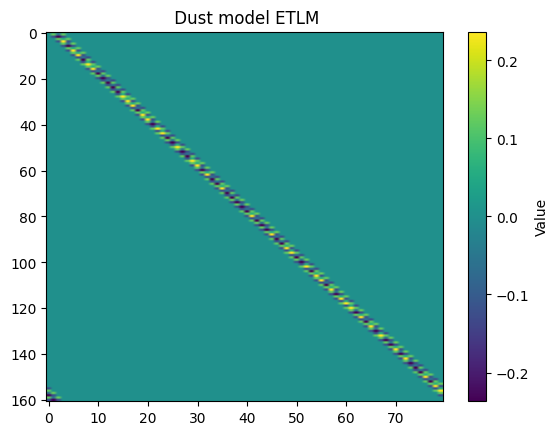

In [ ]:
plt.imshow(N_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()

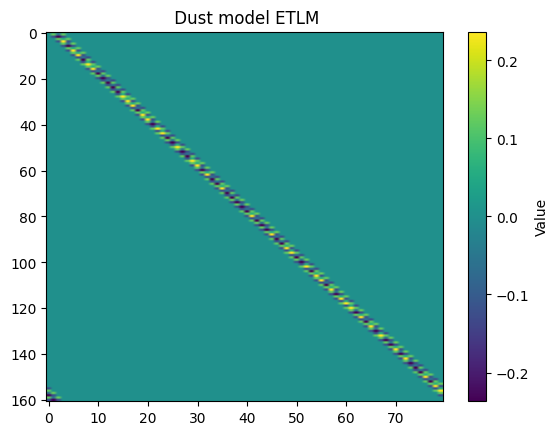

In [ ]:
plt.imshow(L_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()

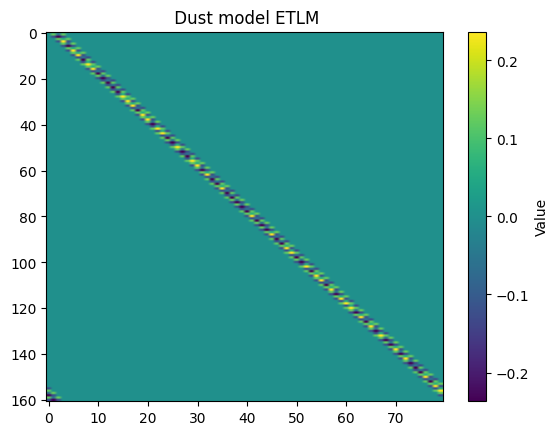

In [ ]:
plt.imshow(K_tilde.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()

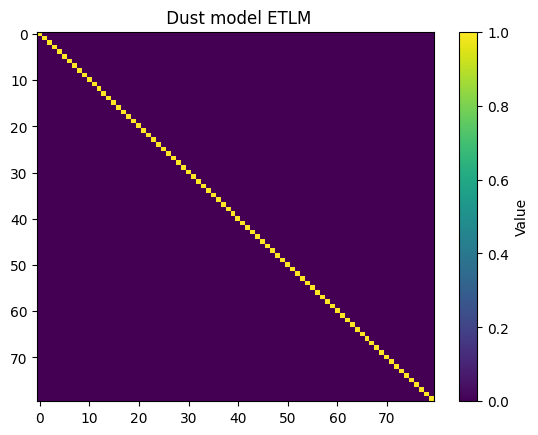

In [ ]:
M1 = torch.matmul(torch.linalg.pinv(N_tilde), L_tilde)
plt.imshow(M1.cpu().numpy(),aspect='auto', cmap='viridis')
plt.colorbar(label='Value')
plt.title(" Dust model ETLM")
plt.show()

In [ ]:
print(M1)


tensor([[ 1.0000e+00, -3.0418e-07, -1.9434e-07,  ...,  4.9207e-09,
         -4.9367e-07, -2.2826e-07],
        [-2.0602e-07,  1.0000e+00,  3.2398e-08,  ..., -1.9071e-07,
          1.8188e-08, -2.1057e-08],
        [-2.1469e-07, -2.2060e-07,  1.0000e+00,  ...,  1.1128e-07,
          2.2890e-08, -1.0850e-07],
        ...,
        [ 1.0649e-07,  2.0179e-07, -2.0271e-07,  ...,  1.0000e+00,
         -3.1462e-09,  2.9815e-07],
        [-3.3367e-07,  9.5055e-09, -3.5643e-08,  ...,  1.7921e-07,
          1.0000e+00,  2.0491e-07],
        [-3.2127e-07, -2.2088e-07,  1.1831e-07,  ...,  1.8452e-07,
         -5.5338e-09,  1.0000e+00]])
